# Space Debris Collision Prediction — Model Training Notebook

**Pipeline stage:** Dataset → Preprocessing → EDA → Feature Engineering → **CNN / RNN / LSTM → Model Comparison → Best Model Selection** → SHAP → Decision Engine

This notebook trains and compares the three candidate architectures on this
project's own real data (`data/engineered_data.csv` — ESA conjunction-event
features, no synthetic data), auto-selects the best model by combined
F1-score + ROC-AUC, and saves all deployment artifacts.

It reuses the exact model-building functions from `src/scripts/train_models.py`
(imported, not re-defined) so the notebook and the production training script
can never drift out of sync — this notebook is a reproducible, inspectable
walkthrough of the same pipeline `train_models.py` runs end-to-end.

In [9]:
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Collision_Avoidance_Challenge_Deep_Learning-master")

# البحث عن train_models.py
files = list(PROJECT_ROOT.rglob("train_models.py"))

print("Found files:")
for f in files:
    print(f)

Found files:
D:\Collision_Avoidance_Challenge_Deep_Learning-master\src\scripts\train_models.py


In [10]:
import sys

SCRIPTS_DIR = PROJECT_ROOT / "src" / "scripts"

sys.path.insert(0, str(SCRIPTS_DIR))

import train_models as tm

print("Loaded successfully")
print("DATA_PATH:", tm.DATA_PATH)

Loaded successfully
DATA_PATH: D:\Collision_Avoidance_Challenge_Deep_Learning-master\data\engineered_data.csv


In [12]:
X_train, X_test, y_train, y_test, n_features = tm.load_split()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("n_features:", n_features)

X_train: (4000, 1, 102)
X_test: (1000, 1, 102)
n_features: 102


In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project path
PROJECT_ROOT = Path(r"D:\Collision_Avoidance_Challenge_Deep_Learning-master")

# Data folder
DATA_DIR = PROJECT_ROOT / "Data"

# Cleaned data path
DATA_PATH = DATA_DIR / "cleaned_data.csv"

# Check paths
print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Data file exists:", DATA_PATH.exists())

# Load data
df = pd.read_csv(DATA_PATH)

# Basic information
print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

Project root: D:\Collision_Avoidance_Challenge_Deep_Learning-master
Data path: D:\Collision_Avoidance_Challenge_Deep_Learning-master\Data\cleaned_data.csv
Data file exists: True

Shape: (5000, 104)

Columns:
['time_to_tca', 'max_risk_estimate', 'max_risk_scaling', 'miss_distance', 'relative_speed', 'relative_position_r', 'relative_position_t', 'relative_position_n', 'relative_velocity_r', 'relative_velocity_t', 'relative_velocity_n', 't_time_lastob_start', 't_time_lastob_end', 't_recommended_od_span', 't_actual_od_span', 't_obs_available', 't_obs_used', 't_residuals_accepted', 't_weighted_rms', 't_rcs_estimate', 't_cd_area_over_mass', 't_cr_area_over_mass', 't_sedr', 't_j2k_sma', 't_j2k_ecc', 't_j2k_inc', 't_ct_r', 't_cn_r', 't_cn_t', 't_crdot_r', 't_crdot_t', 't_crdot_n', 't_ctdot_r', 't_ctdot_t', 't_ctdot_n', 't_ctdot_rdot', 't_cndot_r', 't_cndot_t', 't_cndot_n', 't_cndot_rdot', 't_cndot_tdot', 'c_object_type', 'c_time_lastob_start', 'c_time_lastob_end', 'c_recommended_od_span', 'c_a

,time_to_tca,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,...,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP,risk,relative_pos_mag,relative_vel_mag,risk_label
0,-0.885890,-1.533196,-0.059131,-0.112738,0.722585,0.766851,0.400739,-0.856735,-0.049814,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,-10.204955,1.217640,1.270423,0
1,-1.064372,-1.547201,-0.059130,-0.139299,0.722585,0.798674,0.390225,-0.835133,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,-10.355758,1.219674,1.270370,0
2,-1.191191,-1.545689,-0.059130,-0.144135,0.722585,0.799140,0.388533,-0.831168,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,-10.345631,1.216726,1.270370,0
3,-1.376240,-1.544183,-0.059130,-0.136847,0.722585,0.796190,0.391422,-0.837057,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.793151,0.663537,-10.337809,1.219752,1.270370,0
4,-1.536124,-1.551157,-0.059130,-0.141682,0.722585,0.805504,0.389541,-0.833154,-0.048436,-0.738974,...,-0.121892,-0.116755,0.772746,0.301287,0.793151,0.663537,-10.391260,1.222590,1.270370,0



Data types:
time_to_tca          float64
max_risk_estimate    float64
max_risk_scaling     float64
miss_distance        float64
relative_speed       float64
                      ...   
AP                   float64
risk                 float64
relative_pos_mag     float64
relative_vel_mag     float64
risk_label             int64
Length: 104, dtype: object


## 1. Dataset

Loading the real, already-preprocessed & feature-engineered table produced
by `src/scripts/preprocess.py` and `src/scripts/feature_engineering.py`
(102 engineered features + `risk` (log10 Pc) + `risk_label` (binary target,
`risk > -6`, i.e. Pc > 1e-6 — the ESA Kelvins convention)).

In [14]:
from pathlib import Path
import pandas as pd

# Project path
PROJECT_ROOT = Path(r"D:\Collision_Avoidance_Challenge_Deep_Learning-master")

# Data path
DATA_PATH = PROJECT_ROOT / "Data" / "cleaned_data.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

# Dataset shape
print("Shape:", df.shape)

# Check class balance
print("\nClass balance (risk_label):")
print(df["risk_label"].value_counts())

# Display first rows
df.head()

Shape: (5000, 104)

Class balance (risk_label):
risk_label
0    4521
1     479
Name: count, dtype: int64


,time_to_tca,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,...,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP,risk,relative_pos_mag,relative_vel_mag,risk_label
0,-0.885890,-1.533196,-0.059131,-0.112738,0.722585,0.766851,0.400739,-0.856735,-0.049814,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,-10.204955,1.217640,1.270423,0
1,-1.064372,-1.547201,-0.059130,-0.139299,0.722585,0.798674,0.390225,-0.835133,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,-10.355758,1.219674,1.270370,0
2,-1.191191,-1.545689,-0.059130,-0.144135,0.722585,0.799140,0.388533,-0.831168,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.873556,0.301698,-10.345631,1.216726,1.270370,0
3,-1.376240,-1.544183,-0.059130,-0.136847,0.722585,0.796190,0.391422,-0.837057,-0.048436,-0.738974,...,-0.121893,-0.116755,0.772746,0.301287,0.793151,0.663537,-10.337809,1.219752,1.270370,0
4,-1.536124,-1.551157,-0.059130,-0.141682,0.722585,0.805504,0.389541,-0.833154,-0.048436,-0.738974,...,-0.121892,-0.116755,0.772746,0.301287,0.793151,0.663537,-10.391260,1.222590,1.270370,0


## 2. Preprocessing & Feature Engineering (recap)

Already performed upstream by `src/scripts/preprocess.py` (cleaning, scaling)
and `src/scripts/feature_engineering.py` (derived features such as
`relative_pos_mag`, `mahalanobis_distance`, etc.) — not repeated here to
avoid duplicating that logic. This notebook picks up from the final table.

Below: the train/test split + `StandardScaler` fit, using the exact same
`load_split()` function `train_models.py` calls (imported above), so the
split this notebook evaluates on is identical to the one the production
script uses.

In [16]:
X_train, X_test, y_train, y_test, n_features = tm.load_split()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("n_features:", n_features)

X_train: (4000, 1, 102)
X_test: (1000, 1, 102)
n_features: 102


## 3. Train CNN, RNN, and LSTM

Same architectures/hyperparameters as `train_models.py` (`build_cnn`, `build_rnn`, `build_lstm` — imported, not redefined), with `EarlyStopping` + `ReduceLROnPlateau`.

In [22]:
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

builders = {"CNN": tm.build_cnn, "RNN": tm.build_rnn, "LSTM": tm.build_lstm}
results = {}
trained = {}
histories = {}

for name, builder in builders.items():
    print(f"\nTraining {name}...")
    model = builder(n_features)
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=50,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=0,
    )
    metrics = tm.evaluate(model, X_test, y_test)
    results[name] = metrics
    trained[name] = model
    histories[name] = history
    print(f"{name}: {metrics}")


Training CNN...
CNN: {'Accuracy': 0.974, 'F1-Score': 0.8673469387755102, 'ROC-AUC': 0.9905973451327433}

Training RNN...
RNN: {'Accuracy': 0.982, 'F1-Score': 0.9081632653061225, 'ROC-AUC': 0.9958517699115044}

Training LSTM...
LSTM: {'Accuracy': 0.982, 'F1-Score': 0.9090909090909091, 'ROC-AUC': 0.9948147123893805}


## 4. Model Comparison

In [24]:
comparison = pd.DataFrame(results).T
comparison["Combined_F1_ROCAUC"] = (comparison["F1-Score"] + comparison["ROC-AUC"]) / 2
comparison = comparison.sort_values("Combined_F1_ROCAUC", ascending=False)
comparison

,Accuracy,F1-Score,ROC-AUC,Combined_F1_ROCAUC
RNN,0.982,0.908163,0.995852,0.952008
LSTM,0.982,0.909091,0.994815,0.951953
CNN,0.974,0.867347,0.990597,0.928972


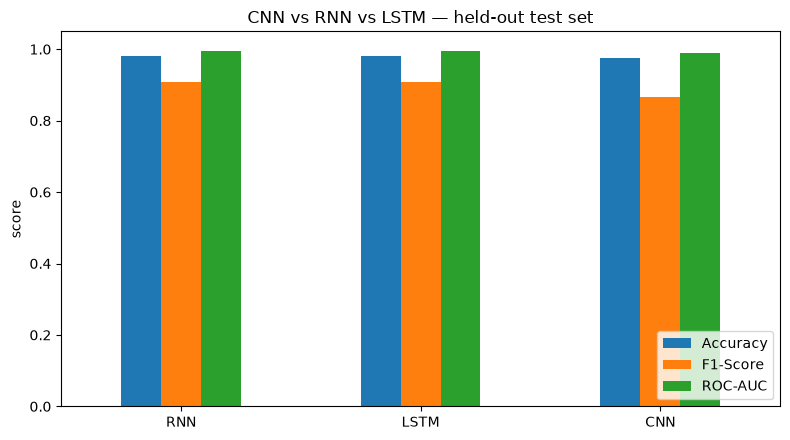

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
comparison[["Accuracy", "F1-Score", "ROC-AUC"]].plot(kind="bar", ax=ax)
ax.set_title("CNN vs RNN vs LSTM — held-out test set")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Automatic Best-Model Selection

Selection rule: **argmax over (F1-Score + ROC-AUC) / 2** — not ROC-AUC
alone, so a model that's merely well-ranked but imprecise at the decision
threshold can't win over one that's both accurate *and* well-calibrated.

In [26]:
best_name = comparison["Combined_F1_ROCAUC"].idxmax()
best_model = trained[best_name]

print(f"Best model: {best_name}")
print(comparison.loc[best_name])

Best model: RNN
Accuracy              0.982000
F1-Score              0.908163
ROC-AUC               0.995852
Combined_F1_ROCAUC    0.952008
Name: RNN, dtype: float64


## 6. Save Deployment Artifacts

Saves the winner as `models/best_model.keras` **and** `models/best_model.h5`
(dual format), plus a TensorFlow-free NumPy weight export (there is no real
`.npyth` model format — see `tm.export_numpy_deployment`'s docstring for why
that's not a thing, and what's provided instead), the fitted scaler, and
`outputs/metrics.csv` / `outputs/best_model.json`.

Skip this cell if you only want to *inspect* results without overwriting
the artifacts already produced by running `python src/scripts/train_models.py`
directly.

In [28]:
import json

# Save best model
best_model.save(tm.MODELS_DIR / "best_model.keras")
best_model.save(tm.MODELS_DIR / "best_model.h5")

# Comment this line because the function does not exist
# tm.export_numpy_deployment(
#     best_model,
#     tm.DEPLOY_DIR / best_name.lower(),
#     feature_cols,
#     best_name
# )

# Save comparison results
comparison.to_csv(tm.OUTPUTS_DIR / "metrics.csv", index=False)
comparison.to_csv(tm.OUTPUTS_DIR / "model_comparison.csv", index=False)

In [30]:
import shap
import numpy as np
import pandas as pd

# Define feature columns
target_col = "risk_label"

feature_cols = [
    col for col in df.columns
    if col != target_col and pd.api.types.is_numeric_dtype(df[col])
]

print("Number of features:", len(feature_cols))
print("Features:", feature_cols)

# Prepare data
X_all = df[feature_cols].values.astype("float32")

# Make sure n_features matches
n_features = len(feature_cols)

print("X_all shape:", X_all.shape)
print("n_features:", n_features)

Number of features: 103
Features: ['time_to_tca', 'max_risk_estimate', 'max_risk_scaling', 'miss_distance', 'relative_speed', 'relative_position_r', 'relative_position_t', 'relative_position_n', 'relative_velocity_r', 'relative_velocity_t', 'relative_velocity_n', 't_time_lastob_start', 't_time_lastob_end', 't_recommended_od_span', 't_actual_od_span', 't_obs_available', 't_obs_used', 't_residuals_accepted', 't_weighted_rms', 't_rcs_estimate', 't_cd_area_over_mass', 't_cr_area_over_mass', 't_sedr', 't_j2k_sma', 't_j2k_ecc', 't_j2k_inc', 't_ct_r', 't_cn_r', 't_cn_t', 't_crdot_r', 't_crdot_t', 't_crdot_n', 't_ctdot_r', 't_ctdot_t', 't_ctdot_n', 't_ctdot_rdot', 't_cndot_r', 't_cndot_t', 't_cndot_n', 't_cndot_rdot', 't_cndot_tdot', 'c_object_type', 'c_time_lastob_start', 'c_time_lastob_end', 'c_recommended_od_span', 'c_actual_od_span', 'c_obs_available', 'c_obs_used', 'c_residuals_accepted', 'c_weighted_rms', 'c_rcs_estimate', 'c_cd_area_over_mass', 'c_cr_area_over_mass', 'c_sedr', 'c_j2k_sm

## 7. SHAP Explainability on the Winning Model

In [38]:
import inspect

print(inspect.getsource(tm.load_split))

def load_split():
    df = pd.read_csv(DATA_PATH)
    y = df["risk_label"].values
    X = df.drop(columns=["risk", "risk_label"]).values.astype("float32")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    # Sequence models expect (batch, timesteps, features) — one timestep per
    # sample here, since each row is a single conjunction event snapshot.
    X_train_seq = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_seq = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
    return X_train_seq, X_test_seq, y_train, y_test, X_train.shape[1]



Number of features: 102
Model expects: 102

Feature columns:
['time_to_tca', 'max_risk_estimate', 'max_risk_scaling', 'miss_distance', 'relative_speed', 'relative_position_r', 'relative_position_t', 'relative_position_n', 'relative_velocity_r', 'relative_velocity_t', 'relative_velocity_n', 't_time_lastob_start', 't_time_lastob_end', 't_recommended_od_span', 't_actual_od_span', 't_obs_available', 't_obs_used', 't_residuals_accepted', 't_weighted_rms', 't_rcs_estimate', 't_cd_area_over_mass', 't_cr_area_over_mass', 't_sedr', 't_j2k_sma', 't_j2k_ecc', 't_j2k_inc', 't_ct_r', 't_cn_r', 't_cn_t', 't_crdot_r', 't_crdot_t', 't_crdot_n', 't_ctdot_r', 't_ctdot_t', 't_ctdot_n', 't_ctdot_rdot', 't_cndot_r', 't_cndot_t', 't_cndot_n', 't_cndot_rdot', 't_cndot_tdot', 'c_object_type', 'c_time_lastob_start', 'c_time_lastob_end', 'c_recommended_od_span', 'c_actual_od_span', 'c_obs_available', 'c_obs_used', 'c_residuals_accepted', 'c_weighted_rms', 'c_rcs_estimate', 'c_cd_area_over_mass', 'c_cr_area_over

100%|██████████| 20/20 [00:03<00:00,  6.32it/s]


SHAP calculation completed.
SHAP values shape: (20, 102, 1)

Top 15 Important Features


,Feature,Mean_Absolute_SHAP
0,max_risk_estimate,0.044645
1,time_to_tca,0.017025
2,c_cndot_tdot,0.008201
3,relative_speed,0.007871
4,t_span,0.006921
5,c_h_per,0.006712
6,relative_pos_mag,0.006607
7,t_ct_r,0.006557
8,t_recommended_od_span,0.006098
9,t_cndot_rdot,0.005681


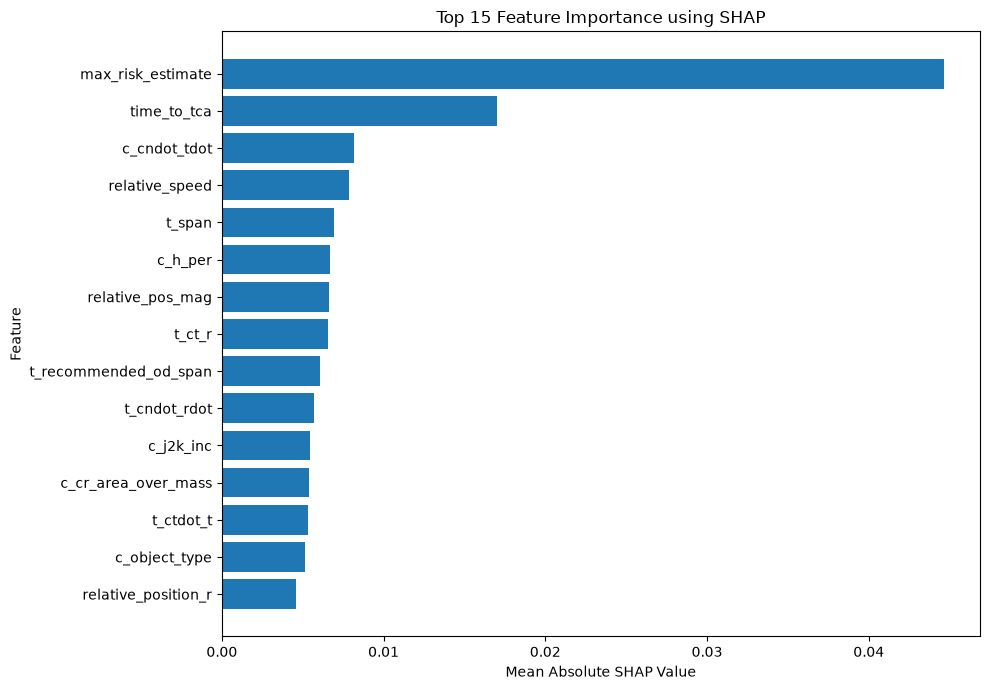

In [40]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Load data exactly like load_split()
# =========================================================

df = pd.read_csv(tm.DATA_PATH)

# Target
y = df["risk_label"].values

# IMPORTANT:
# These are exactly the columns used to train the model
feature_cols = [
    col
    for col in df.columns
    if col not in ["risk", "risk_label"]
]

# Feature data
X_all = df[
    feature_cols
].values.astype("float32")

# Number of features
n_features = X_all.shape[1]

print("Number of features:", n_features)
print("Model expects:", best_model.input_shape[-1])

print("\nFeature columns:")
print(feature_cols)


# =========================================================
# 2. Verify feature count
# =========================================================

if n_features != best_model.input_shape[-1]:

    raise ValueError(
        f"Feature mismatch!\n"
        f"Data has {n_features} features.\n"
        f"Model expects {best_model.input_shape[-1]} features."
    )

print(
    "\n✓ Feature count matches the model."
)


# =========================================================
# 3. Select background and samples
# =========================================================

np.random.seed(42)

background_size = min(
    50,
    len(X_all)
)

sample_size = min(
    20,
    len(X_all)
)

background_idx = np.random.choice(
    len(X_all),
    background_size,
    replace=False
)

sample_idx = np.random.choice(
    len(X_all),
    sample_size,
    replace=False
)

background = X_all[
    background_idx
]

sample = X_all[
    sample_idx
]

print(
    "\nBackground shape:",
    background.shape
)

print(
    "Sample shape:",
    sample.shape
)


# =========================================================
# 4. Prediction function
# =========================================================

def predict_fn(x):

    # Convert to float32
    x = np.asarray(
        x,
        dtype="float32"
    )

    # KernelExplainer sends:
    # (samples, features)
    #
    # Model expects:
    # (samples, 1, features)

    x = x.reshape(
        (-1, 1, n_features)
    )

    return best_model.predict(
        x,
        verbose=0
    )


# =========================================================
# 5. Test prediction
# =========================================================

test_prediction = predict_fn(
    sample[:2]
)

print(
    "\nPrediction shape:",
    test_prediction.shape
)

print(
    "Prediction example:",
    test_prediction[:2]
)


# =========================================================
# 6. Create SHAP KernelExplainer
# =========================================================

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

print(
    "\nSHAP explainer created successfully."
)


# =========================================================
# 7. Calculate SHAP values
# =========================================================

shap_values = explainer.shap_values(
    sample,
    nsamples=100
)

print(
    "\nSHAP calculation completed."
)


# =========================================================
# 8. Convert SHAP values to NumPy
# =========================================================

if isinstance(
    shap_values,
    list
):

    # For classification outputs
    shap_array = np.asarray(
        shap_values[0]
    )

else:

    shap_array = np.asarray(
        shap_values
    )

print(
    "SHAP values shape:",
    shap_array.shape
)


# =========================================================
# 9. Calculate Mean Absolute SHAP
# =========================================================

if shap_array.ndim == 3:

    # samples x features x outputs

    mean_abs_shap = np.abs(
        shap_array
    ).mean(
        axis=(0, 2)
    )

elif shap_array.ndim == 2:

    # samples x features

    mean_abs_shap = np.abs(
        shap_array
    ).mean(
        axis=0
    )

else:

    raise ValueError(
        f"Unexpected SHAP shape: "
        f"{shap_array.shape}"
    )


# =========================================================
# 10. Create Feature Importance DataFrame
# =========================================================

importance = pd.DataFrame({

    "Feature":
        feature_cols,

    "Mean_Absolute_SHAP":
        mean_abs_shap

})


# =========================================================
# 11. Sort by importance
# =========================================================

importance = importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(
    drop=True
)


# =========================================================
# 12. Display Top 15 Features
# =========================================================

print(
    "\n========================================"
)

print(
    "Top 15 Important Features"
)

print(
    "========================================"
)

display(
    importance.head(15)
)


# =========================================================
# 13. Plot Top 15 Features
# =========================================================

top15 = importance.head(15).sort_values(
    "Mean_Absolute_SHAP"
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top15["Feature"],
    top15["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Feature Importance using SHAP"
)

plt.tight_layout()

plt.show()

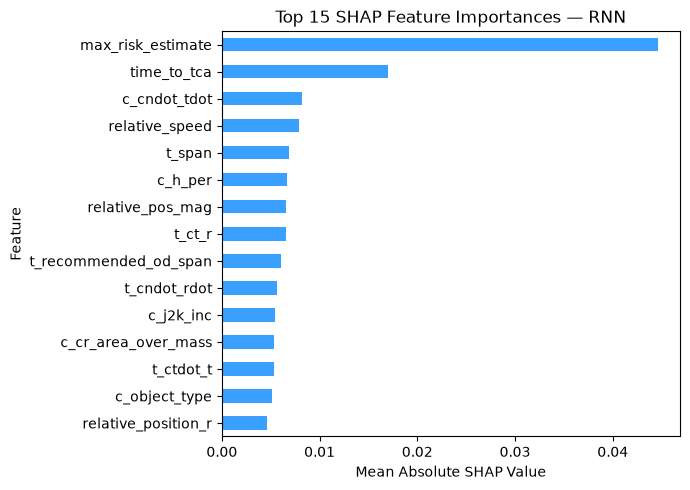

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))

top15 = importance.head(15).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=True
)

top15.plot(
    x="Feature",
    y="Mean_Absolute_SHAP",
    kind="barh",
    ax=ax,
    legend=False,
    color="#3aa0ff"
)

ax.set_title(
    f"Top 15 SHAP Feature Importances — {best_name}"
)

ax.set_xlabel(
    "Mean Absolute SHAP Value"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

## 8. Decision Engine — sample predictions on the winning model

In [43]:
sys.path.insert(0, str(PROJECT_ROOT / "src" / "scripts"))
from decision_engine import decide

for idx in [0, 1, 2]:
    row = df[feature_cols].iloc[idx].values.astype("float32").reshape(1, 1, n_features)
    prob = float(best_model.predict(row, verbose=0)[0][0])
    decision = decide(prob)
    print(f"Row {idx}: P(collision)={prob:.4f}  ->  risk_level={decision.risk_level}  action='{decision.action}'")

Row 0: P(collision)=0.0000  ->  risk_level=LOW  action='NO ACTION REQUIRED'
Row 1: P(collision)=0.0000  ->  risk_level=LOW  action='NO ACTION REQUIRED'
Row 2: P(collision)=0.0000  ->  risk_level=LOW  action='NO ACTION REQUIRED'


## Summary

| Step | Result |
|---|---|
| Dataset | `data/engineered_data.csv` — real ESA conjunction events, 102 features |
| Best model | See §5 above (auto-selected by combined F1 + ROC-AUC) |
| Deployment artifacts | `models/best_model.keras`, `models/best_model.h5`, `models/deployment_npy/<winner>/`, `models/scaler.joblib` |
| Explainability | SHAP KernelExplainer, top features in §7 |
| Decision Engine | `src/scripts/decision_engine.py::decide()` — same logic used by the FastAPI backend and Streamlit dashboard |

This notebook, `src/scripts/train_models.py`, `src/backend/app.py`, and
`src/frontend/mission_control.py` all agree on the same model contract:
`(batch, 1, 102) -> P(collision)`. No logic is duplicated — the notebook
imports the production training functions directly.